In [1]:
import torch
t_version = str(torch.__version__)
s_src = f"https://pytorch-geometric.com/whl/torch-{t_version}.html"
sp_src = f"https://pytorch-geometric.com/whl/torch-{t_version}.html"
!pip install torch-scatter -f $s_src
!pip install torch-sparse -f $sp_src
!pip install torch-geometric
!pip install -q git+https://github.com/snap-stanford/deepsnap.git

Looking in links: https://pytorch-geometric.com/whl/torch-2.2.2+cpu.html
Looking in links: https://pytorch-geometric.com/whl/torch-2.2.2+cpu.html


  ERROR: Error [WinError 2] The system cannot find the file specified while executing command git clone -q https://github.com/snap-stanford/deepsnap.git 'C:\Users\SRMAPCSELAB2022-346\AppData\Local\Temp\pip-req-build-e3ht3_x8'
ERROR: Cannot find command 'git' - do you have 'git' installed and in your PATH?


In [2]:
import torch_geometric
torch_geometric.__version__

'2.6.1'

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import MessagePassing
from tqdm import trange
from torch_geometric.utils import add_self_loops, softmax
from sklearn.metrics import roc_auc_score, average_precision_score
from torch_scatter import scatter
from torch_geometric.utils import degree  

class GraphNNStack(nn.Module):
    def __init__(self, input_features, hidden_features, output_features, configuration, return_embeddings=True):
        super(GraphNNStack, self).__init__()

        assert configuration.model_type == 'GraphContrastiveLearning'

        self.num_layers = min(configuration.num_layers, 5)
        self.dropout = configuration.dropout
        self.return_embeddings = return_embeddings

        self.convs = nn.ModuleList()

        self.convs.append(GraphContrastiveLearning(input_features, hidden_features, dropout=self.dropout))

        for _ in range(self.num_layers - 1):
            self.convs.append(GraphContrastiveLearning(hidden_features, hidden_features, dropout=self.dropout))
            
    def select_conv_layer(self, conv_type):
        if conv_type == 'GraphContrastiveLearning':
            return GraphContrastiveLearning
        else:
            raise ValueError(f"Unknown model type: {conv_type}")         

    def forward(self, data):
        x, edge_index = data.x, data.edge_index

        for i, conv in enumerate(self.convs):
            x = conv(x, edge_index)

            if i < len(self.convs) - 1:
                x = F.relu(x)
                x = F.dropout(x, p=self.dropout, training=self.training)

        return x
    
       

    def decode(self, z, edge_label_index):
        return (z[edge_label_index[0]] * z[edge_label_index[1]]).sum(dim=-1)

In [4]:
import torch
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import MessagePassing
from torch_geometric.utils import add_self_loops, degree, softmax
from torch.nn import Parameter

class GraphContrastiveLearning(MessagePassing):
    def __init__(self, in_channels, out_channels, dropout=0.0):
        super(GraphContrastiveLearning, self).__init__(aggr='mean')

        self.in_channels = in_channels
        self.out_channels = out_channels
        self.dropout = dropout

        # Encoder (GNN layer)
        self.lin = nn.Linear(in_channels, out_channels)

        # Projection head (important for contrastive learning)
        self.projection_head = nn.Sequential(
            nn.Linear(out_channels, out_channels),
            nn.ReLU(),
            nn.Linear(out_channels, out_channels)
        )

        self.reset_parameters()

    def reset_parameters(self):
        self.lin.reset_parameters()
        for layer in self.projection_head:
            if hasattr(layer, 'reset_parameters'):
                layer.reset_parameters()

    def forward(self, x, edge_index):
        # Add self-loops
        edge_index, _ = add_self_loops(edge_index, num_nodes=x.size(0))

        # Linear transform
        x = self.lin(x)

        # Message passing
        x = self.propagate(edge_index, x=x)

        # Activation
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        # Projection
        z = self.projection_head(x)

        return z

    def message(self, x_j):
        return x_j

    def aggregate(self, inputs, index, dim_size=None):
        return scatter(inputs, index, dim=0, dim_size=dim_size, reduce='mean')

    def contrastive_loss(self, z1, z2, temperature=0.5):
        z1 = F.normalize(z1, dim=-1)
        z2 = F.normalize(z2, dim=-1)

        sim_matrix = torch.mm(z1, z2.t()) / temperature

        exp_sim = torch.exp(sim_matrix)
        loss = -torch.log(exp_sim.diag() / (exp_sim.sum(dim=1) + 1e-8)).mean()

        return loss

In [5]:
import torch.optim as optim
def setup_optimizer_and_scheduler(configuration, model_params):
    weight_decay = configuration.weight_decay
    trainable_params = filter(lambda p: p.requires_grad, model_params)

    if configuration.optimizer == 'adam':
        optimizer = torch.optim.Adam(trainable_params, lr=configuration.learning_rate, weight_decay=weight_decay)
    elif configuration.optimizer == 'sgd':
        optimizer = torch.optim.SGD(trainable_params, lr=configuration.learning_rate, momentum=0.95, weight_decay=weight_decay)
    else:
        optimizer = torch.optim.Adam(trainable_params, lr=configuration.learning_rate, weight_decay=weight_decay)

    return None, optimizer

In [6]:
import torch.optim as optim
import time
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
from torch_geometric.data import HeteroData, Data
import zipfile
import torch.nn.functional as F
from sklearn.metrics import roc_auc_score, average_precision_score, precision_score, recall_score, f1_score
from torch_geometric.data import Data
import torch
import torch.nn.functional as F


def download_and_extract_gowalla():
    """
    Extract Gowalla dataset from uploaded ZIP file
    and return the actual dataset directory.
    """

    print("Extracting Gowalla dataset...")

    zip_file = "gowalla.zip"

    extract_path = "gowalla"

    # Create extraction directory
    if not os.path.exists(extract_path):
        os.makedirs(extract_path)

    # Extract ZIP
    with zipfile.ZipFile(zip_file, 'r') as zip_ref:
        zip_ref.extractall(extract_path)

    print("Dataset extracted successfully!")

    print(f"Files extracted to: {extract_path}")

    print("\nDirectory structure:")

    for root, dirs, files in os.walk(extract_path):

        level = root.replace(
            extract_path,
            ''
        ).count(os.sep)

        indent = ' ' * 2 * level

        print(
            f"{indent}"
            f"{os.path.basename(root)}/"
        )

        subindent = ' ' * 2 * (level + 1)

        for file in files[:10]:

            print(
                f"{subindent}"
                f"{file}"
            )

    # Gowalla folder
    dataset_folder = os.path.join(
        extract_path,
        "gowalla"
    )

    if os.path.exists(dataset_folder):

        print(
            "\nGowalla dataset folder found:"
        )

        print(dataset_folder)

        print("\nDataset files:")

        for file in os.listdir(dataset_folder):

            print(f"  - {file}")

        return dataset_folder

    # Fallback
    print(
        "\nWarning:"
        " gowalla folder not found."
    )

    return extract_path


def load_gowalla_heterogeneous(data_path):

    print(
        f"Loading Gowalla dataset "
        f"from: {data_path}"
    )

    data = HeteroData()

    user_file = os.path.join(
        data_path,
        "user_list.txt"
    )

    user_df = pd.read_csv(
        user_file,
        sep=' ',
        skiprows=1,
        names=['org_id', 'remap_id']
    )

    num_users = len(user_df)

    item_file = os.path.join(
        data_path,
        "item_list.txt"
    )

    item_df = pd.read_csv(
        item_file,
        sep=' ',
        skiprows=1,
        names=['org_id', 'remap_id']
    )

    num_items = len(item_df)

    print(f"Users : {num_users}")
    print(f"Items : {num_items}")

    # Node features
    data['user'].x = torch.ones(
        (num_users, 1),
        dtype=torch.float
    )

    data['item'].x = torch.ones(
        (num_items, 1),
        dtype=torch.float
    )

    data['user'].num_nodes = num_users
    data['item'].num_nodes = num_items

    # ==========================================
    # TRAIN EDGES
    # ==========================================

    edge_list = []

    train_file = os.path.join(
        data_path,
        "train.txt"
    )

    with open(
        train_file,
        "r",
        encoding="utf-8"
    ) as f:

        for line in f:

            tokens = line.strip().split()

            if len(tokens) < 2:
                continue

            user = int(tokens[0])

            items = [
                int(x)
                for x in tokens[1:]
            ]

            for item in items:

                edge_list.append(
                    [user, item]
                )

    edge_index = torch.tensor(
        edge_list,
        dtype=torch.long
    ).t().contiguous()

    data[
        'user',
        'interacts',
        'item'
    ].edge_index = edge_index

    data[
        'user',
        'interacts',
        'item'
    ].original_edge_index = (
        edge_index.clone()
    )

    # ==========================================
    # TEST EDGES
    # ==========================================

    test_edges = []

    test_file = os.path.join(
        data_path,
        "test.txt"
    )

    with open(
        test_file,
        "r",
        encoding="utf-8"
    ) as f:

        for line in f:

            tokens = line.strip().split()

            if len(tokens) < 2:
                continue

            user = int(tokens[0])

            items = [
                int(x)
                for x in tokens[1:]
            ]

            for item in items:

                test_edges.append(
                    [user, item]
                )

    test_edge_index = torch.tensor(
        test_edges,
        dtype=torch.long
    ).t().contiguous()

    data[
        'user',
        'interacts',
        'item'
    ].test_edge_index = (
        test_edge_index
    )

    print("\nFINAL STATISTICS")

    print(f"Users: {num_users}")
    print(f"Items: {num_items}")

    print(
        f"Training edges: "
        f"{edge_index.shape[1]}"
    )

    print(
        f"Testing edges: "
        f"{test_edge_index.shape[1]}"
    )

    return data




def convert_gowalla_to_homogeneous(data):
    """Convert Gowalla heterogeneous graph to homogeneous graph"""

    print("Converting Gowalla to homogeneous graph...")

    num_users = data['user'].num_nodes
    num_items = data['item'].num_nodes

    total_nodes = num_users + num_items

    edge_indices = []

    if ('user', 'interacts', 'item') in data.edge_types:

        user_item = data[
            'user',
            'interacts',
            'item'
        ].edge_index

        # user -> item

        user_item_adj = user_item.clone()

        user_item_adj[1] += num_users

        # item -> user

        item_user = torch.stack(
            [
                user_item[1],
                user_item[0]
            ],
            dim=0
        )

        item_user[0] += num_users

        edge_indices.append(
            user_item_adj
        )

        edge_indices.append(
            item_user
        )

    if len(edge_indices) > 0:

        edge_index = torch.cat(
            edge_indices,
            dim=1
        )

        edge_index = torch.unique(
            edge_index,
            dim=1
        )

        print(
            f"Created "
            f"{edge_index.shape[1]} "
            f"edges"
        )

    else:

        edge_index = torch.empty(
            (2, 0),
            dtype=torch.long
        )

        print(
            "Warning: No edges found!"
        )

    user_features = data[
        'user'
    ].x.float()

    item_features = data[
        'item'
    ].x.float()

    max_dim = max(
        user_features.shape[1],
        item_features.shape[1]
    )

    if user_features.shape[1] < max_dim:

        user_features = F.pad(
            user_features,
            (
                0,
                max_dim -
                user_features.shape[1]
            )
        )

    if item_features.shape[1] < max_dim:

        item_features = F.pad(
            item_features,
            (
                0,
                max_dim -
                item_features.shape[1]
            )
        )

    x = torch.cat(
        [
            user_features,
            item_features
        ],
        dim=0
    )

    original_edges = data[
        'user',
        'interacts',
        'item'
    ].edge_index.clone()

    test_edges = data[
        'user',
        'interacts',
        'item'
    ].test_edge_index.clone()

    print(
        f"Stored original "
        f"user-item edges: "
        f"{original_edges.shape[1]}"
    )

    homogeneous_data = Data(
        x=x,
        edge_index=edge_index,
        num_nodes=total_nodes,
        num_users=num_users,
        num_items=num_items,
        original_user_item_edges=original_edges,
        test_user_item_edges=test_edges
    )

    print(
        f"Homogeneous graph created "
        f"with {total_nodes} nodes"
    )

    return homogeneous_data

def print_dataset_details(homogeneous_data):
    """Print dataset details for Gowalla"""

    print("\n" + "=" * 60)

    print("Dataset name: Gowalla")

    print(f"Total nodes: {homogeneous_data.num_nodes}")

    print(
        f"Total edges: "
        f"{homogeneous_data.edge_index.shape[1]}"
    )

    print(
        f"Number of user nodes: "
        f"{homogeneous_data.num_users}"
    )

    print(
        f"Number of item nodes: "
        f"{homogeneous_data.num_items}"
    )

    print(
        f"Feature dimension: "
        f"{homogeneous_data.x.shape[1]}"
    )

    print("=" * 60)
    
    
def prepare_link_prediction_data(homogeneous_data):

    print("\n" + "=" * 60)
    print("Preparing Gowalla link prediction data...")
    print("=" * 60)

    num_users = homogeneous_data.num_users

    # =====================================================
    # Positive edges
    # =====================================================

    if (not hasattr(
            homogeneous_data,
            "original_user_item_edges")
        or
        homogeneous_data.original_user_item_edges is None):

        raise ValueError(
            "No original user-item edges found!"
        )

    train_pos_edge_index = (
        homogeneous_data
        .original_user_item_edges
        .clone()
    )

    train_pos_edge_index[1] += num_users

    test_pos_edge_index = (
        homogeneous_data
        .test_user_item_edges
        .clone()
    )

    test_pos_edge_index[1] += num_users

    print(
        f"Training Positive edges: "
        f"{train_pos_edge_index.shape[1]}"
    )

    print(
        f"Testing Positive edges: "
        f"{test_pos_edge_index.shape[1]}"
    )

    homogeneous_data.train_pos_edge_index = (
        train_pos_edge_index
    )

    
    num_users = homogeneous_data.num_users
    num_items = homogeneous_data.num_items

    num_neg_samples = test_pos_edge_index.size(1)

    # ==========================================
    # Build Positive Edge Set
    # ==========================================

    positive_edges = set()

    all_positive_edges = torch.cat(
        [
        train_pos_edge_index,
        test_pos_edge_index
        ],
        dim=1
    )

    for i in range(all_positive_edges.shape[1]):

        u = all_positive_edges[0, i].item()

        v = all_positive_edges[1, i].item()

        positive_edges.add((u, v))

    # ==========================================
    # Generate True Negative Samples
    # ==========================================

    negative_edges = []

    while len(negative_edges) < num_neg_samples:

        u = np.random.randint(
            0,
            num_users
        )

        v = np.random.randint(
            num_users,
            num_users + num_items
        )

        if (u, v) not in positive_edges:

            negative_edges.append(
                [u, v]
            )

    test_neg_edge_index = torch.tensor(
        negative_edges,
        dtype=torch.long
    ).t().contiguous()
    
    test_pos_label = torch.ones(
        test_pos_edge_index.size(1)
    )

    test_neg_label = torch.zeros(
        test_neg_edge_index.size(1)
    )

    homogeneous_data.test_edge_index = torch.cat(
        [
            test_pos_edge_index,
            test_neg_edge_index
        ],
        dim=1
    )

    homogeneous_data.test_edge_label = torch.cat(
        [
            test_pos_label,
            test_neg_label
        ]
    )

    print("\nDataset Statistics")

    print(
        f"Train edges: "
        f"{train_pos_edge_index.shape[1]}"
    )

    print(
        f"Test positive edges: "
        f"{test_pos_edge_index.shape[1]}"
    )

    print(
        f"Test negative edges: "
        f"{test_neg_edge_index.shape[1]}"
    )

    return homogeneous_data

def train_link_prediction_model(data, configuration):

    model = GraphNNStack(
        data.num_node_features,
        configuration.hidden_dim,
        configuration.hidden_dim,
        configuration,
        return_embeddings=True
    )

    optimizer = optim.Adam(
        model.parameters(),
        lr=configuration.learning_rate,
        weight_decay=configuration.weight_decay
    )

    losses = []
    
    
    
    for epoch in trange(
            configuration.epochs,
            desc="Link Prediction Training"):

        model.train()
        optimizer.zero_grad()

        z = model(data)

        pos_edge_index = data.train_pos_edge_index

        if pos_edge_index.size(1) == 0:
            print("No positive edges!")
            break

        

        pos_edge_batch = pos_edge_index

        neg_users = pos_edge_batch[0]

        neg_items = torch.randint(
            data.num_users,
            data.num_users + data.num_items,
            (
                pos_edge_batch.size(1),
            ),
            device=pos_edge_batch.device
        )

        neg_edge_index = torch.stack(
            [
            neg_users,
            neg_items
            ],
            dim=0
        )

                
        pos_pred = model.decode(
            z,
            pos_edge_batch
        )

        neg_pred = model.decode(
            z,
            neg_edge_index
        )

        pos_loss = -torch.log(
            torch.sigmoid(pos_pred) + 1e-15
        ).mean()

        neg_loss = -torch.log(
            1 - torch.sigmoid(neg_pred) + 1e-15
        ).mean()

        loss = pos_loss + neg_loss

        loss.backward()
        optimizer.step()

        losses.append(loss.item())

    # ==================================================
    # Final Evaluation
    # ==================================================

    model.eval()

    with torch.no_grad():

        z = model(data)

        test_size = min(
            50000,
            data.test_edge_index.size(1)
        )

        idx = torch.randperm(
            data.test_edge_index.size(1)
        )[:test_size]

        test_edges = (
            data.test_edge_index[:, idx]
        )

        test_labels = (
            data.test_edge_label[idx]
        )

        test_pred = torch.sigmoid(
            model.decode(
                z,
                test_edges
            )
        )

        test_auc = roc_auc_score(
            test_labels.cpu().numpy(),
            test_pred.cpu().numpy()
        )

        test_ap = average_precision_score(
            test_labels.cpu().numpy(),
            test_pred.cpu().numpy()
        )

        test_binary = (
            test_pred > 0.5
        ).float()

        test_accuracy = (
            (test_binary == test_labels)
            .float()
            .mean()
            .item()
        )

        test_precision = precision_score(
            test_labels.cpu().numpy(),
            test_binary.cpu().numpy(),
            zero_division=0
        )

        test_recall = recall_score(
            test_labels.cpu().numpy(),
            test_binary.cpu().numpy(),
            zero_division=0
        )

        test_f1 = f1_score(
            test_labels.cpu().numpy(),
            test_binary.cpu().numpy(),
            zero_division=0
        )

    test_metrics = {
        'accuracy': test_accuracy,
        'precision': test_precision,
        'recall': test_recall,
        'f1': test_f1,
        'auc': test_auc,
        'ap': test_ap
    }

    return (
        losses,
        model,
        test_metrics
    )

def evaluate_recommendation(
        model,
        data,
        k_list=[5, 10, 20]):

    model.eval()

    HR = {k: [] for k in k_list}
    NDCG = {k: [] for k in k_list}
    MRR = []

    with torch.no_grad():

        z = model(data)

        pos_edges = data.test_edge_index[
            :,
            data.test_edge_label == 1
        ]

        if pos_edges.shape[1] == 0:

            print(
                "No positive test edges!"
            )

            return {
                f'HR@{k}': 0
                for k in k_list
            }

        # ======================================
        # Gowalla is large
        # evaluate only subset
        # ======================================

        max_eval_edges = min(
            10000,
            pos_edges.shape[1]
        )

        eval_idx = torch.randperm(
            pos_edges.shape[1]
        )[:max_eval_edges]

        pos_edges = pos_edges[:, eval_idx]

        all_items = set(
            range(
                data.num_users,
                data.num_users +
                data.num_items
            )
        )

        for edge in pos_edges.t():

            user = edge[0].item()

            pos_item = edge[1].item()

            # ==================================
            # Items already seen
            # ==================================

            user_seen = set(
                data.train_pos_edge_index[1][
                    data.train_pos_edge_index[0]
                    == user
                ].cpu().numpy()
            )

            candidate_items = list(
                all_items - user_seen
            )

            # Remove positive item from negative candidates
            if pos_item in candidate_items:
                candidate_items.remove(pos_item)

            if len(candidate_items) < 999:

                continue

            neg_items = np.random.choice(
            candidate_items,
            999,
            replace=False
            )

            candidates = (
                list(neg_items)
                + [pos_item]
            )

            
            users = torch.full(
                (len(candidates),),
                user,
                dtype=torch.long,
                device=z.device
            )

            items = torch.tensor(
                candidates,
                dtype=torch.long,
                device=z.device
            )

            edge_index = torch.stack(
                [
                    users,
                    items
                ]
            )

            scores = model.decode(
                z,
                edge_index
            ).cpu().numpy()

            ranking = np.argsort(
                scores
            )[::-1]

            ranked_items = [
                candidates[i]
                for i in ranking
            ]

            for k in k_list:

                if pos_item in ranked_items[:k]:

                    HR[k].append(1)

                    rank = (
                        ranked_items.index(
                            pos_item
                        ) + 1
                    )

                    NDCG[k].append(
                        1 /
                        np.log2(rank + 1)
                    )

                else:

                    HR[k].append(0)

                    NDCG[k].append(0)

            rank = (
                ranked_items.index(
                    pos_item
                ) + 1
            )

            MRR.append(
                1 / rank
            )

    results = {}

    for k in k_list:

        results[f'HR@{k}'] = (
            np.mean(HR[k])
            if HR[k]
            else 0
        )

        results[f'NDCG@{k}'] = (
            np.mean(NDCG[k])
            if NDCG[k]
            else 0
        )

    results['MRR'] = (
        np.mean(MRR)
        if MRR
        else 0
    )

    return results

class Config:
    def __init__(self, parameters):
        self.__dict__.update(parameters)


STEP 1: Loading Gowalla Dataset
Extracting Gowalla dataset...
Dataset extracted successfully!
Files extracted to: gowalla

Directory structure:
gowalla/
  gowalla/
    item_list.txt
    README.md
    test.txt
    train.txt
    user_list.txt
    .ipynb_checkpoints/

Gowalla dataset folder found:
gowalla\gowalla

Dataset files:
  - .ipynb_checkpoints
  - item_list.txt
  - README.md
  - test.txt
  - train.txt
  - user_list.txt
Loading Gowalla dataset from: gowalla\gowalla
Users : 29858
Items : 40981

FINAL STATISTICS
Users: 29858
Items: 40981
Training edges: 810128
Testing edges: 217242

STEP 2: Converting to Homogeneous Graph
Converting Gowalla to homogeneous graph...
Created 1620256 edges
Stored original user-item edges: 810128
Homogeneous graph created with 70839 nodes

Dataset name: Gowalla
Total nodes: 70839
Total edges: 1620256
Number of user nodes: 29858
Number of item nodes: 40981
Feature dimension: 1

STEP 3: Preparing Data for Link Prediction

Preparing Gowalla link prediction 

Link Prediction Training: 100%|██████████████████████████████████████████████████████| 300/300 [03:30<00:00,  1.43it/s]



FINAL RESULTS
Model: GraphContrastiveLearning
Dataset: Gowalla (Link Prediction)

--- LINK PREDICTION METRICS ---
AUC: 0.4717
AP: 0.4878

--- RECOMMENDATION METRICS ---
HR@5: 0.1036
HR@10: 0.1203
HR@20: 0.1573
NDCG@5: 0.0726
NDCG@10: 0.0780
NDCG@20: 0.0873
MRR: 0.0711

Time Taken: 210.59 seconds


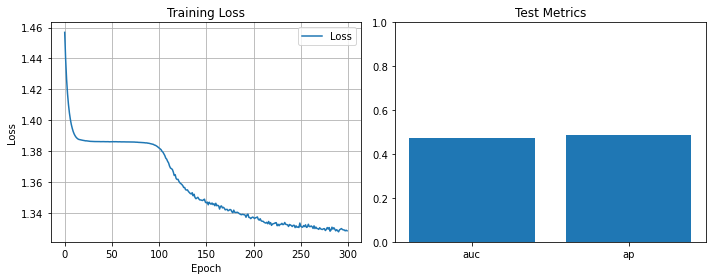

In [7]:
def main_link_prediction():

    configurations = [
        {
            'model_type': 'GraphContrastiveLearning',
            'dataset': 'Gowalla',
            'num_layers': 2,
            'heads': 1,
            'hidden_dim': 64,
            'dropout': 0.5,
            'epochs': 300,
            'weight_decay': 1e-4,
            'learning_rate': 0.001
        },
    ]

    for config_dict in configurations:

        config = Config(config_dict)

        device = torch.device(
            'cuda'
            if torch.cuda.is_available()
            else 'cpu'
        )

        print("\n" + "=" * 60)
        print("STEP 1: Loading Gowalla Dataset")
        print("=" * 60)

        data_path = download_and_extract_gowalla()

        heterogeneous_data = (
            load_gowalla_heterogeneous(
                data_path
            )
        )

        print("\n" + "=" * 60)
        print("STEP 2: Converting to Homogeneous Graph")
        print("=" * 60)

        homogeneous_data = (
            convert_gowalla_to_homogeneous(
                heterogeneous_data
            )
        )

        homogeneous_data = (
            homogeneous_data.to(device)
        )

        print_dataset_details(
            homogeneous_data
        )

        print("\n" + "=" * 60)
        print("STEP 3: Preparing Data for Link Prediction")
        print("=" * 60)

        homogeneous_data = (
            prepare_link_prediction_data(
                homogeneous_data
            )
        )

        print("\n" + "=" * 60)

        print(
            f"STEP 4: Training "
            f"{config.model_type} "
            f"for LINK PREDICTION"
        )

        print("=" * 60)

        start_time = time.time()

        losses, best_model, test_metrics = (
            train_link_prediction_model(
                homogeneous_data,
                config
            )
        )

        end_time = time.time()

        elapsed_time = (
            end_time - start_time
        )

        print("\n" + "=" * 60)
        print("FINAL RESULTS")
        print("=" * 60)

        print(
            f"Model: "
            f"{config.model_type}"
        )

        print(
            f"Dataset: "
            f"{config.dataset} "
            f"(Link Prediction)"
        )

        print(
            "\n--- LINK PREDICTION METRICS ---"
        )

        print(
            f"AUC: "
            f"{test_metrics['auc']:.4f}"
        )

        print(
            f"AP: "
            f"{test_metrics['ap']:.4f}"
        )

        print(
            "\n--- RECOMMENDATION METRICS ---"
        )

        rec_metrics = (
            evaluate_recommendation(
                best_model,
                homogeneous_data
            )
        )

        if rec_metrics:

            print(
                f"HR@5: "
                f"{rec_metrics['HR@5']:.4f}"
            )

            print(
                f"HR@10: "
                f"{rec_metrics['HR@10']:.4f}"
            )

            print(
                f"HR@20: "
                f"{rec_metrics['HR@20']:.4f}"
            )

            print(
                f"NDCG@5: "
                f"{rec_metrics['NDCG@5']:.4f}"
            )

            print(
                f"NDCG@10: "
                f"{rec_metrics['NDCG@10']:.4f}"
            )

            print(
                f"NDCG@20: "
                f"{rec_metrics['NDCG@20']:.4f}"
            )

            print(
                f"MRR: "
                f"{rec_metrics['MRR']:.4f}"
            )

        print(
            f"\nTime Taken: "
            f"{elapsed_time:.2f} seconds"
        )

        print("=" * 60)

        # ==================================
        # Plot Results
        # ==================================

        plt.figure(figsize=(10, 4))

        plt.subplot(1, 2, 1)

        plt.title(
            "Training Loss"
        )

        plt.plot(
            losses,
            label="Loss"
        )

        plt.xlabel("Epoch")

        plt.ylabel("Loss")

        plt.legend()

        plt.grid(True)

        plt.subplot(1, 2, 2)

        metrics_to_plot = [
            'auc',
            'ap'
        ]

        values = [
            test_metrics[m]
            for m in metrics_to_plot
        ]

        plt.bar(
            metrics_to_plot,
            values
        )

        plt.title(
            "Test Metrics"
        )

        plt.ylim(0, 1)

        plt.tight_layout()

        plt.show()


# ==========================================
# RUN LINK PREDICTION
# ==========================================

if __name__ == '__main__':

    main_link_prediction()